---
title: Comparando GPU vs CPU
subject: Aprendizaje Profundo
subtitle: Rendimiento según el tipo de hardware
short_title: GPU vs CPU
authors:
  - name: Jorge Anais
    orcid: 0000-0001-9051-1338
    email: jrganais@gmail.com
license: MIT
---

El siguiente código muestra la diferencia de velocidad en calcular multiplicaciones de matrices tanto utilizando GPU como CPU.

In [ ]:
import torch
import time

import matplotlib.pyplot as plt


In [ ]:
def matrix_multiplication(size: int = 5_000) -> tuple[float, float]:
    """
    Medir el tiempo de ejecución de multiplicación de dos matrices aleatorias.
    Parameters:
      `size`: Tamaño de las matrices cuadradas.
    Returns:
      `cpu_time`: Tiempo de ejecución en CPU.
      `gpu_time`: Tiempo de ejecución en GPU.
    """
    # Crear matrices aleatorias
    A = torch.randn(size, size)
    B = torch.randn(size, size)

    # Medir tiempo en CPU
    start_cpu = time.time()
    C_cpu = torch.matmul(A, B)
    end_cpu = time.time()

    cpu_time = end_cpu - start_cpu
    print(f"Tiempo en CPU: {cpu_time:.4f} segundos")

    # Mover matrices a la GPU
    A_gpu = A.to('cuda')
    B_gpu = B.to('cuda')

    # Sincronizar y medir tiempo en GPU
    torch.cuda.synchronize()
    start_gpu = time.time()
    C_gpu = torch.matmul(A_gpu, B_gpu)
    torch.cuda.synchronize()
    end_gpu = time.time()

    gpu_time = end_gpu - start_gpu
    print(f"Tiempo en GPU: {gpu_time:.4f} segundos")

    # Comparación de velocidad
    speedup = (end_cpu - start_cpu) / (end_gpu - start_gpu)
    print(f"Aceleración con GPU: {speedup:.2f}x")

    return cpu_time, gpu_time

Acá se ejecuta la función para una matriz cuadrada de 5000 elementos x 5000 elementos. 

In [ ]:
if torch.cuda.is_available():
    matrix_multiplication(size=5_000)
else:
    print("No se encontraron GPUs disponibles. Modifica la configuración de Colab (Runtime -> Change runtime type)")

Tiempo en CPU: 3.0145 segundos
Tiempo en GPU: 0.2301 segundos
Aceleración con GPU: 13.10x


Ahora iteramos para tamaños crecientes de las matrices y graficamos el tiempo de computo vs el tamaño de la matriz tanto para cpu como para gpu.

In [ ]:
sizes = [500, 1_000, 2_500, 5_000, 10_000]
gpu_times = []
cpu_times = []
for size in sizes:
    print(f"Tamaño de la matriz: {size}x{size}")
    if torch.cuda.is_available():
        cpu_time, gpu_time = matrix_multiplication(size=size)
        gpu_times.append(gpu_time)
        cpu_times.append(cpu_time)

Tamaño de la matriz: 500x500
Tiempo en CPU: 0.0050 segundos
Tiempo en GPU: 0.0005 segundos
Aceleración con GPU: 10.16x
Tamaño de la matriz: 1000x1000
Tiempo en CPU: 0.0234 segundos
Tiempo en GPU: 0.0009 segundos
Aceleración con GPU: 25.09x
Tamaño de la matriz: 2500x2500
Tiempo en CPU: 0.3823 segundos
Tiempo en GPU: 0.0115 segundos
Aceleración con GPU: 33.30x
Tamaño de la matriz: 5000x5000
Tiempo en CPU: 3.0560 segundos
Tiempo en GPU: 0.0873 segundos
Aceleración con GPU: 35.00x
Tamaño de la matriz: 10000x10000
Tiempo en CPU: 25.0336 segundos
Tiempo en GPU: 0.5108 segundos
Aceleración con GPU: 49.01x


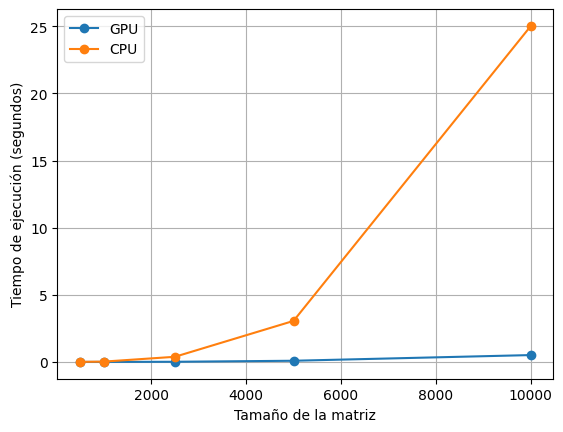

In [ ]:
# Realizamos un gráfico simple
plt.plot(sizes, gpu_times, "o-", label='GPU')
plt.plot(sizes, cpu_times, "o-", label='CPU')
plt.xlabel('Tamaño de la matriz')
plt.ylabel('Tiempo de ejecución (segundos)')
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
# Realizamos un gráfico logaritmico para poder ver mejor los resultados
plt.plot(sizes, gpu_times, "o-", label='GPU')
plt.plot(sizes, cpu_times, "o-", label='CPU')
plt.xlabel('Tamaño de la matriz')
plt.ylabel('Tiempo de ejecución (segundos)')
plt.loglog()
plt.grid(True)
plt.legend()
plt.show()